# 23. To implement transfer learning using a pre-trained CNN model.

## Aim

To implement transfer learning using a pre-trained CNN model for image classification.

## Introduction

Transfer Learning is a Deep Learning technique in which a model trained on a large dataset is reused for a different but related task.

Instead of training a Convolutional Neural Network (CNN) from the beginning, we use the features learned by an already trained model.

In this practical, a pre-trained MobileNetV2 CNN model is used as a feature extractor. A new classification layer is added and trained for the CIFAR-10 image classification task.

## Theory

### Transfer Learning

A CNN trained on a large dataset learns useful visual features such as:

- Edges
- Textures
- Shapes
- Patterns
- Object structures

These learned features can be reused for another image classification problem.

Transfer learning generally consists of the following steps:

1. Load a pre-trained CNN model.
2. Remove the original classification layer.
3. Freeze the pre-trained layers.
4. Add a new classification layer.
5. Train the new layers using the target dataset.
6. Evaluate the model.

### Pre-trained Model

In this practical, **MobileNetV2** is used.

MobileNetV2 is a lightweight CNN architecture designed for efficient image classification and computer vision applications.

The model uses weights pre-trained on the **ImageNet** dataset.

## Dataset

The CIFAR-10 dataset is used in this practical.

CIFAR-10 contains images belonging to 10 different classes:

1. Airplane
2. Automobile
3. Bird
4. Cat
5. Deer
6. Dog
7. Frog
8. Horse
9. Ship
10. Truck

The original images are 32 × 32 pixels.

For demonstration, a smaller subset of the dataset is used to reduce memory consumption and training time.

In [1]:
#Import Libraries
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [10]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Original Training Data:", x_train.shape)
print("Original Testing Data:", x_test.shape)

Original Training Data: (50000, 32, 32, 3)
Original Testing Data: (10000, 32, 32, 3)


In [11]:
#Create Smaller Dataset

# Use a smaller subset to reduce memory usage

x_train_small = x_train[:5000]
y_train_small = y_train[:5000]

x_test_small = x_test[:1000]
y_test_small = y_test[:1000]

print("Training images used:", x_train_small.shape)
print("Testing images used:", x_test_small.shape)

Training images used: (5000, 32, 32, 3)
Testing images used: (1000, 32, 32, 3)


## Display Sample Image

A sample image from the CIFAR-10 dataset is displayed before applying transfer learning.

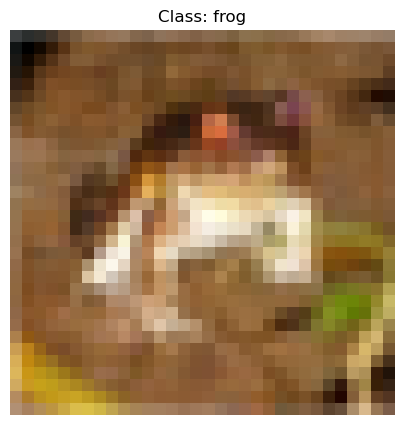

In [13]:
#Display Sample Image

# CIFAR-10 class names
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# Display first training image
plt.figure(figsize=(5, 5))
plt.imshow(x_train_small[0])
plt.title("Class: " + class_names[y_train_small[0][0]])
plt.axis("off")
plt.show()

## Image Preprocessing(Create Preprocessing Function)

MobileNetV2 expects images with a suitable input size.

The CIFAR-10 images are resized from 32 × 32 pixels to 96 × 96 pixels.

The `preprocess_input()` function is then applied to prepare the images for MobileNetV2.

The preprocessing is performed image-by-image using TensorFlow datasets. This reduces memory usage compared with preprocessing the complete dataset at once.

In [15]:
#Create Preprocessing Function
def preprocess_image(image, label):
    # Resize image
    image = tf.image.resize(image, (96, 96))
    
    # Apply MobileNetV2 preprocessing
    image = preprocess_input(image)
    
    return image, label

In [16]:
# Create TensorFlow datasets
train_ds = tf.data.Dataset.from_tensor_slices(
    (x_train_small, y_train_small)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (x_test_small, y_test_small)
)

# Apply preprocessing
train_ds = train_ds.map(
    preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds = test_ds.map(
    preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

# Create batches
train_ds = train_ds.batch(32).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(32).prefetch(tf.data.AUTOTUNE)

print("Dataset preprocessing completed successfully.")

Dataset preprocessing completed successfully.


## Load Pre-trained MobileNetV2

MobileNetV2 is loaded with weights pre-trained on ImageNet.

The original classification layer is removed using `include_top=False`.

The pre-trained layers are frozen so that the learned features are not modified during the initial training.

# Load pre-trained MobileNetV2
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(96, 96, 3)
)

# Freeze the pre-trained model
base_model.trainable = False

print("MobileNetV2 loaded successfully.")

## Build Transfer Learning Model

A new classification head is added to the pre-trained MobileNetV2 model.

The model consists of:

- Pre-trained MobileNetV2
- Global Average Pooling layer
- Dense layer
- Dropout layer
- Softmax output layer with 10 classes

In [18]:
# Create transfer learning model

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(10, activation="softmax")
])

print("Transfer learning model created successfully.")

Transfer learning model created successfully.


## Compile the Model

The model is compiled using:

- Adam optimizer
- Sparse Categorical Cross-Entropy loss
- Accuracy as the evaluation metric

In [19]:
#Compile the Model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


## Train the Model

The pre-trained MobileNetV2 layers are frozen.

Only the newly added classification layers are trained using the CIFAR-10 dataset.

A small number of epochs is used for demonstration.

In [20]:
#Train Model
history = model.fit(
    train_ds,
    epochs=2,
    validation_data=test_ds
)

Epoch 1/2
157/157 ━━━━━━━━━━━━━━━━━━━━ 43s 189ms/step - accuracy: 0.5607 - loss: 1.3904 - val_accuracy: 0.8210 - val_loss: 0.5212
Epoch 2/2
157/157 ━━━━━━━━━━━━━━━━━━━━ 28s 181ms/step - accuracy: 0.8292 - loss: 0.5020 - val_accuracy: 0.8370 - val_loss: 0.4723


## Evaluate the Model

After training, the model is evaluated using the test dataset.

The test accuracy indicates the performance of the transfer learning model on unseen images.

In [21]:
#Evaluate Model
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 136ms/step - accuracy: 0.8543 - loss: 0.4428
Test Loss: 0.4723351299762726
Test Accuracy: 0.8370000123977661


## Training and Validation Accuracy

The training and validation accuracy are plotted to observe the performance of the model during training.

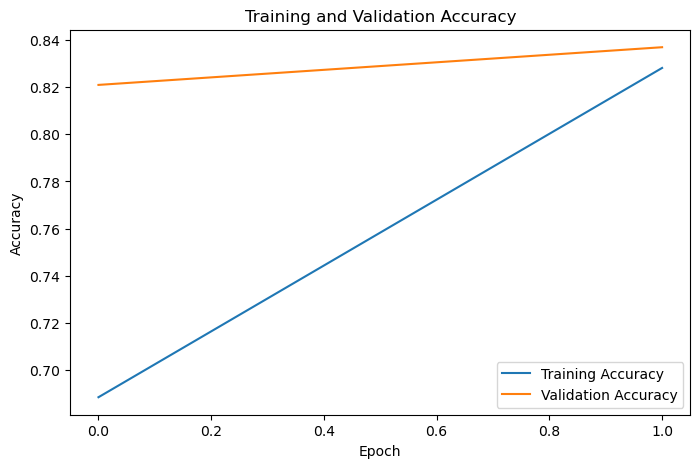

In [23]:
#Accuracy Graph
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

## Make Prediction

The trained transfer learning model is used to classify a test image.

The class with the highest predicted probability is selected as the predicted class.

In [25]:
#Prediction
# Take one batch from the test dataset
for images, labels in test_ds.take(1):
    
    # Select first image from the batch
    sample_image = images[0:1]
    
    # Make prediction
    prediction = model.predict(sample_image, verbose=0)
    
    # Get predicted and actual class
    predicted_class = int(tf.argmax(prediction[0]))
    actual_class = int(labels[0].numpy())

    print("Predicted Class:", class_names[predicted_class])
    print("Actual Class:", class_names[actual_class])

Predicted Class: cat
Actual Class: cat


C:\Users\Smit\AppData\Local\Temp\ipykernel_30444\1539442318.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  actual_class = int(labels[0].numpy())


## Display Prediction

The selected test image is displayed along with its predicted and actual class labels.

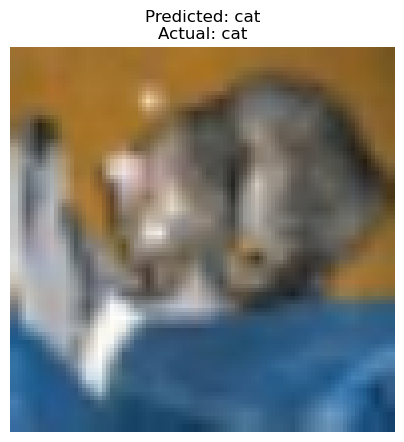

In [27]:
#Display Result
# Display the selected test image

display_image = (sample_image[0].numpy() + 1.0) / 2.0

plt.figure(figsize=(5, 5))
plt.imshow(display_image)

plt.title(
    f"Predicted: {class_names[predicted_class]}\n"
    f"Actual: {class_names[actual_class]}"
)

plt.axis("off")
plt.show()

## Observation

The pre-trained MobileNetV2 model was successfully used for transfer learning.

The convolutional base of MobileNetV2 was frozen and used as a feature extractor.

A new classification head was added for the 10 CIFAR-10 classes.

The model was trained and evaluated using a subset of the CIFAR-10 dataset.

## Result

Transfer learning was successfully implemented using the pre-trained MobileNetV2 CNN model.

The pre-trained CNN was used as a feature extractor, and a new classification head was trained for CIFAR-10 image classification.